In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df[df['GarageYrBlt'].isnull()]['GarageArea'].value_counts()

GarageArea
0    81
Name: count, dtype: int64

In [4]:
categorical_cols_with_na = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "PoolQC", "Fence", "MiscFeature"
]
df[categorical_cols_with_na] = df[categorical_cols_with_na].fillna("None")

In [5]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [6]:
df["LotArea"].isna().sum()

np.int64(0)

In [7]:
numerical_nas = df.select_dtypes(include=['number']).isnull().sum()
numerical_nas = numerical_nas[numerical_nas > 0].sort_values(ascending=False)
numerical_nas

GarageYrBlt    81
MasVnrArea      8
dtype: int64

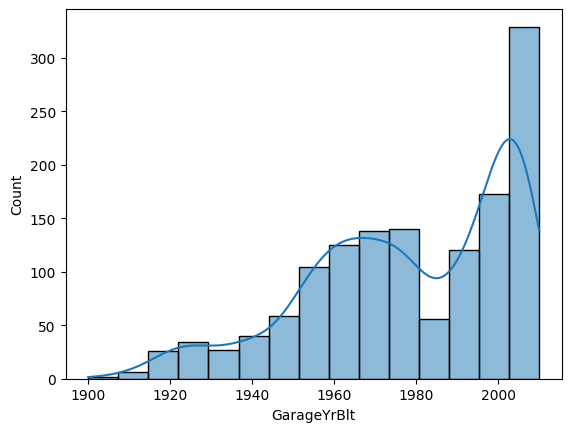

In [8]:
sns.histplot(data=df, x="GarageYrBlt", kde=True)
plt.show()

In [9]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [10]:
numerical_nas = df.select_dtypes(include=['number']).isnull().sum()
numerical_nas = numerical_nas[numerical_nas > 0].sort_values(ascending=False)
numerical_nas

Series([], dtype: int64)

In [11]:
df[df['GarageYrBlt'].isnull()]['GarageArea'].value_counts()

Series([], Name: count, dtype: int64)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector

num_median_imputer = SimpleImputer(strategy='median')
num_zero_imputer = SimpleImputer(strategy='constant', fill_value=0)

# 2. Transformers for Categories (as we defined before)
cat_none_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_generic_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Assemble the Corrected Master Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # A. Street connection exists, just missing data -> Median
        ('num_med', num_median_imputer, ['LotFrontage']),
        
        # B. Feature likely doesn't exist -> Zero
        ('num_zero', num_zero_imputer, ['MasVnrArea', 'GarageYrBlt']),
        
        # C. Specific "None" Categoricals
        ('cat_none', cat_none_pipeline, categorical_cols_with_na),
        
        # D. Generic Fallback for ALL other objects
        ('cat_gen', cat_generic_pipeline, make_column_selector(dtype_include=['object']))
    ],
    remainder='passthrough'
)

